Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import mediapipe as mp
from ultralytics import YOLO

from tensorflow.keras.layers import (
    TimeDistributed, Bidirectional, BatchNormalization
)

Configuration & Data Paths

In [2]:
IMG_SIZE = 224
MAX_FRAMES = 30
BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 1e-4

DATASET_DIR = r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\CombinedDataset"

print("Configuration Loaded")

Configuration Loaded


Face Detection + Cropping 

In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def detect_and_crop_face(frame, target_size=(224, 224)):

    # If frame invalid
    if frame is None or frame.size == 0:
        return np.zeros((224, 224, 3), dtype=np.float32)

    # Convert to gray
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40)
    )

    # If NO face found → use full frame instead of black image
    if len(faces) == 0:

        face = cv2.resize(frame, target_size)

    else:

        # Largest face
        x, y, w, h = max(faces, key=lambda b: b[2] * b[3])

        # Padding
        pad = 20

        x1 = max(0, x - pad)
        y1 = max(0, y - pad)

        x2 = min(frame.shape[1], x + w + pad)
        y2 = min(frame.shape[0], y + h + pad)

        face = frame[y1:y2, x1:x2]

        # Safety check
        if face.size == 0:
            face = cv2.resize(frame, target_size)

        else:
            face = cv2.resize(face, target_size)

    # Convert BGR → RGB
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

    # Convert to float
    face = face.astype(np.float32)

    # Proper ResNet preprocessing
    face = preprocess_input(face)

    return face

Extract Frames and Normalization

In [4]:
def extract_frames(video_path, max_frames=30):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return np.zeros((max_frames, 224, 224, 3), dtype=np.float32)

    frame_indices = np.linspace(0, total_frames - 1, max_frames, dtype=int)
    current_frame = 0
    target_idx = 0

    while cap.isOpened() and target_idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
            
        if current_frame in frame_indices:
            face = detect_and_crop_face(frame)
            
            # NORMALIZATION
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)   # BGR to RGB
            face = preprocess_input(face.astype(np.float32))
            
            frames.append(face)
            target_idx += 1
            
        current_frame += 1

    cap.release()

    # Padding
    while len(frames) < max_frames:
        frames.append(frames[-1].copy())

    return np.array(frames, dtype=np.float32)

LOAD VIDEO PATHS

In [5]:
def load_video_paths(max_videos_per_class=None, shuffle=True, seed=42):
    video_paths = []
    labels = []
    for label, class_name in enumerate(['Real', 'Fake']):
        folder = os.path.join(DATASET_DIR, class_name)
        if not os.path.exists(folder):
            continue
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
        if max_videos_per_class:
            files = files[:max_videos_per_class]
        for file in files:
            video_paths.append(os.path.join(folder, file))
            labels.append(label)
    
    combined = list(zip(video_paths, labels))
    random.shuffle(combined)
    video_paths, labels = zip(*combined)
    return list(video_paths), np.array(labels, dtype=np.int32)

FEATURE EXTRACTION

In [9]:
print("\nFeature Extraction Starting...")

video_paths, y = load_video_paths(max_videos_per_class=500)

# ResNet50 Feature Extractor
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

feature_extractor = Model(
    inputs=base_model.input,
    outputs=x
)

X_features = []

for path in tqdm(video_paths, desc="Extracting Features"):
    try:
        frames = extract_frames(path)                          # (60, 224, 224, 3)
        #frames = np.expand_dims(frames, axis=0)                # (1, 60, 224, 224, 3)
        
        features = feature_extractor.predict(frames, verbose=0)  # (1, 60, 7, 7, 2048)
        
        
        X_features.append(features.astype(np.float32))
    except Exception as e:
        print(f"Error on {path}: {e}")
        X_features.append(np.zeros((MAX_FRAMES, 2048), dtype=np.float32))

X_features = np.array(X_features)
np.save('video_features_resnet.npy', X_features)
np.save('video_labels.npy', y)

print(f"Feature Extraction Completed! Shape: {X_features.shape}")


Feature Extraction Starting...


Extracting Features: 100%|██████████| 1000/1000 [2:12:19<00:00,  7.94s/it] 


Feature Extraction Completed! Shape: (1000, 30, 2048)


In [17]:
print(X_features.shape)
print(X_features[0].shape)
print(np.min(X_features), np.max(X_features))
print(np.isnan(X_features).sum())

(1000, 30, 2048)
(30, 2048)
0.0 26.601627
0


LSTM TRAINING

In [20]:
print("\nLSTM Training Starting...")

X = np.load('video_features_resnet.npy')
y = np.load('video_labels.npy')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

def build_lstm_model():
    inputs = Input(shape=(MAX_FRAMES, 2048))

    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64))(x)
    x = Dropout(0.3)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_lstm_model()
model.summary()

callbacks = [
    ModelCheckpoint('Deep_Fake_Video_Detection.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    #EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("Training Completed Successfully!")


LSTM Training Starting...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 30, 256)        │     2,229,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,410,241 (9.19 MB)

 Trainable params: 2,410,241 (9.19 MB)

...

Epoch 1/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5558 - loss: 0.6805
Epoch 1: val_accuracy improved from None to 0.75000, saving model to Deep_Fake_Video_Detection.h5



Epoch 1: finished saving model to Deep_Fake_Video_Detection.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6162 - loss: 0.6418 - val_accuracy: 0.7500 - val_loss: 0.5388 - learning_rate: 1.0000e-04
Epoch 2/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7450 - loss: 0.5342
Epoch 2: val_accuracy improved from 0.75000 to 0.78500, saving model to Deep_Fake_Video_Detection.h5



Epoch 2: finished saving model to Deep_Fake_Video_Detection.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7175 - loss: 0.5475 - val_accuracy: 0.7850 - val_loss: 0.4990 - learning_rate: 1.0000e-04
Epoch 3/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7925 - loss: 0.4701
Epoch 3: val_accuracy did not improve from 0.78500
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7650 - loss: 0.4982 - val_accuracy: 0.6700 - val_loss: 0.5485 - learning_rate: 1.0000e-04
Epoch 4/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7643 - loss: 0.4782
Epoch 4: val_accuracy did not improve from 0.78500
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7825 - loss: 0.4521 - val_accuracy: 0.6550 - val_loss: 0.5798 - learning_rate: 1.0000e-04
Epoch 5/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7906 - loss: 0.4367
Epoch 5: val_accuracy did not improve from 0.78500
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8138 - loss: 0.4256 - val_ac


Epoch 8: finished saving model to Deep_Fake_Video_Detection.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8662 - loss: 0.3283 - val_accuracy: 0.7900 - val_loss: 0.4844 - learning_rate: 1.0000e-04
Epoch 9/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8728 - loss: 0.3019
Epoch 9: val_accuracy did not improve from 0.79000
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8750 - loss: 0.2964 - val_accuracy: 0.7400 - val_loss: 0.5586 - learning_rate: 1.0000e-04
Epoch 10/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8945 - loss: 0.2381
Epoch 10: val_accuracy improved from 0.79000 to 0.80000, saving model to Deep_Fake_Video_Detection.h5



Epoch 10: finished saving model to Deep_Fake_Video_Detection.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8913 - loss: 0.2583 - val_accuracy: 0.8000 - val_loss: 0.5392 - learning_rate: 1.0000e-04
Epoch 11/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9110 - loss: 0.2411
Epoch 11: val_accuracy did not improve from 0.80000

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9000 - loss: 0.2483 - val_accuracy: 0.7650 - val_loss: 0.6110 - learning_rate: 1.0000e-04
Epoch 12/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9049 - loss: 0.2473
Epoch 12: val_accuracy did not improve from 0.80000
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9300 - loss: 0.1929 - val_accuracy: 0.7750 - val_loss: 0.6263 - learning_rate: 5.0000e-05
Epoch 13/20
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9431 - loss: 0.1489
Epoch 13: val_accuracy did not improve from 0.80000

return np.array(X_batch, dtype=np.float32)

Batch size = 64

Every Video = 100 frames

Every frame size = 224x224

Color channel = 3 (RGB)

datatype = float32

Loading all of these into memory together is taking about 3.59 GB of RAM.

A video's memory: 

100 × 224 × 224 × 3 × 4 bytes 

≈ 57 MB

In batch Size 64: 

57 MB × 64

≈ 3.6 GB

In batch Size 32: 1.8 GB

In batch Size 16: 912 MB

In batch Size 8: 456 MB

In batch Size 4: 228 MB

PLOT ACCURACY & LOSS GRAPH


Plotting Training History...


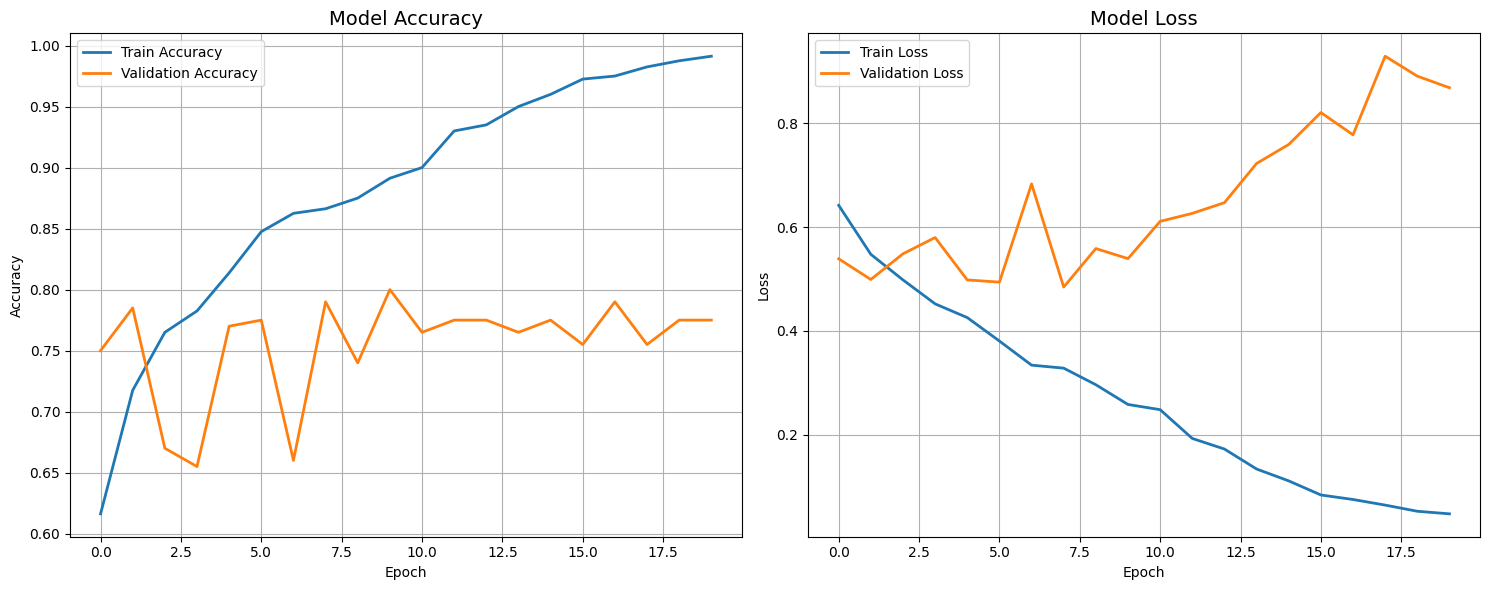

Graph Saved as 'training_history.png'


<Figure size 640x480 with 0 Axes>

In [21]:
print("\nPlotting Training History...")

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Save the graph as image
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("Graph Saved as 'training_history.png'")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\deepfake.h5")

INFERENCE FUNCTION

==========Flow==========

Video

   ↓

Frames

   ↓

ResNet50

   ↓

(30,2048) Features

   ↓

BiLSTM

   ↓

REAL / FAKE

In [47]:
def predict_video(video_path):
    try:
        # Step 1: Extract frames + face detection + preprocessing
        frames = extract_frames(video_path)          # Shape: (30, 224, 224, 3)
        
        # Step 2: Extract ResNet features
        # We need to predict one by one or in small batches because of memory
        features_list = []
        
        for i in range(len(frames)):
            frame = np.expand_dims(frames[i], axis=0)   # (1, 224, 224, 3)
            feat = feature_extractor.predict(frame, verbose=0)
            features_list.append(feat[0])
        
        features = np.array(features_list)              # (30, 2048)
        
        # Step 3: Add batch dimension for LSTM
        features = np.expand_dims(features, axis=0)     # (1, 30, 2048)
        
        # Step 4: Predict using your trained LSTM model
        pred = model.predict(features, verbose=0)[0][0]
        
        # Step 5: Result
        label = "FAKE" if pred > 0.5 else "REAL"
        confidence = pred if pred > 0.5 else (1 - pred)
        
        print(f"\nVideo: {os.path.basename(video_path)}")
        print(f"Prediction: {label}")
        print(f"Confidence: {confidence*100:.2f}%")
        
        return label, confidence
    
    except Exception as e:
        print(f"Error processing video: {e}")
        return "ERROR", 0.0

In [48]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\Deep_Fake_Video_Detection.h5")

print("Model loaded successfully!")
print("Input shape expected:", model.input_shape)

Model loaded successfully!
Input shape expected: (None, 30, 2048)


Making predictions on test set...


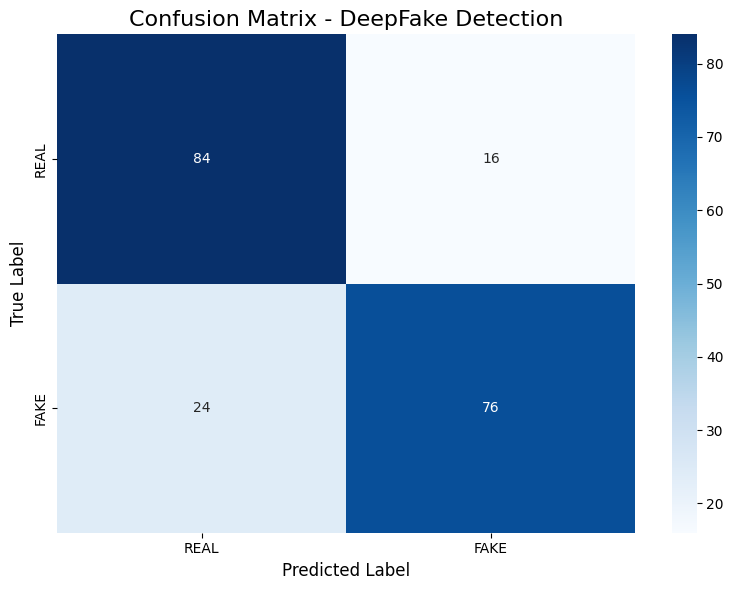


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        REAL       0.78      0.84      0.81       100
        FAKE       0.83      0.76      0.79       100

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200


Overall Accuracy: 80.00%


In [52]:
# Test data load
X_test = np.load('video_features_resnet.npy')
y_test = np.load('video_labels.npy')

_, X_test, _, y_test = train_test_split(X_test, y_test, test_size=0.2, stratify=y_test, random_state=42)

print("Making predictions on test set...")

# Prediction
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'])

plt.title('Confusion Matrix - DeepFake Detection', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

# Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

In [55]:
predict_video(r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\Fake2.mp4")


Video: Fake2.mp4
Prediction: FAKE
Confidence: 98.80%


('FAKE', np.float32(0.98798376))